# Spatial-DISE Dataset Exploration

This notebook explores **Spatial-DISE**, a unified benchmark for evaluating
**spatial reasoning in vision–language models (VLMs)**.
It loads and inspects the `DISE-benchmark.csv` question file, examines the dataset
structure, and visualizes images from the associated folders to support qualitative
analysis and evaluation workflows.

Dataset page:
[https://huggingface.co/datasets/TACPS-liv/Spatial-DISE](https://huggingface.co/datasets/TACPS-liv/Spatial-DISE)

---

## Dataset

**Spatial-DISE** is designed to systematically assess spatial intelligence in VLMs,
covering a wide range of spatial skills such as **3D perception**, **spatial
transformation**, and **geometric reasoning** across multiple difficulty levels.
The dataset includes both **synthetic** and **real-world** images and organizes
questions by category, difficulty, and spatial reasoning type.

### Dataset citation

```bibtex
@article{huang2025spatialdise,
  title        = {Spatial-DISE: A Unified Benchmark for Evaluating Spatial Reasoning in Vision-Language Models},
  author       = {Huang, Xinmiao and He, Qisong and Huang, Zhenglin and Wang, Boxuan and Li, Zhuoyun and Cheng, Guangliang and Dong, Yi and Huang, Xiaowei},
  year         = {2025},
  journal      = {arXiv preprint arXiv:2510.13394},
  archivePrefix = {arXiv}
}
```

---

Code for loading, inspecting, and visualizing the Spatial-DISE dataset
was written by **Masoud Jafaripour** for research analysis and VLM evaluation
purposes.
This notebook and its code are **not affiliated with nor endorsed by the dataset
authors**.

In [ ]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

ROOT = "./SPATIAL_DISE"
CSV_PATH = os.path.join(ROOT, "DISE-benchmark.csv")
IMG_ROOT = os.path.join(ROOT, "images", "synthetic")

In [13]:
import glob

files = sorted(glob.glob("**/*.csv", recursive=True))
files


['DISE-benchmark.csv']

In [19]:
import pandas as pd

CSV_PATH = files[0]  # or select explicitly if multiple
df = pd.read_csv(
    CSV_PATH,
    engine="python",
    on_bad_lines="skip"   # or "warn"
)

df.head()


question                                                                                                                                                                                                                                                                 \
The two views above show the same 3D structure ... "A B                                                  C                                                                                                                                                                                                                        
                                                      B                                                  C                                                                                                                                                                                                                        
The two images above show a 3D structure from d... "A B                                                  C                                                                                                                                                                                                                        
The two views above show the same 3D structure ... "A B                                                  C                                                                                                                                                                                                                        
The two images above show a 3D structure from d... "A B                                                  C                                                                                                                                                                                                                        

                                                         options             \
The two views above show the same 3D structure ... "A B            D"         
                                                      B            D"         
The two images above show a 3D structure from d... "A B            D"         
The two views above show the same 3D structure ... "A B            D"         
The two images above show a 3D structure from d... "A B            D"         

                                                          answer  \
The two views above show the same 3D structure ... "A B   D        
                                                      B   A        
The two images above show a 3D structure from d... "A B   C        
The two views above show the same 3D structure ... "A B   D        
The two images above show a 3D structure from d... "A B   C        

                                                          category          \
The two views above show the same 3D structure ... "A B   3D Combination     
                                                      B   3D Combination     
The two images above show a 3D structure from d... "A B   3D Combination     
The two views above show the same 3D structure ... "A B   3D Combination     
The two images above show a 3D structure from d... "A B   3D Combination     

                                                         image                                                                              \
The two views above show the same 3D structure ... "A B   images/synthetic/merged/3D_combination/easy/m...                                   
                                                      B   images/synthetic/merged/3D_combination/easy/m...                                   
The two images above show a 3D structure from d... "A B   images/synthetic/merged/3D_combination/easy/m...                                   
The two views above show the same 3D structure ... "A B   images/synthetic/merged/3D_combination/easy/m...                                   
The two images above show a 3D structure from d... "A 

In [29]:
expected = [
    "answer",
    "category",
    "difficulty",
    "source",
    "dise_category",
    "image",
    "question_image_path",
    "question_image_1_path",
    "question_image_2_path",
    "option_a_image_path",
    "option_b_image_path",
    "option_c_image_path",
    "option_d_image_path",
]

existing = [c for c in expected if c in df.columns]


Number of questions: 0

Sample questions:
Series([], Name: 0, dtype: str)

Number of images: 18176
Sample image paths:
['images\\synthetic\\merged\\3D_combination\\easy\\merged_question_0200.png', 'images\\synthetic\\merged\\3D_combination\\easy\\merged_question_0201.png', 'images\\synthetic\\merged\\3D_combination\\easy\\merged_question_0202.png']


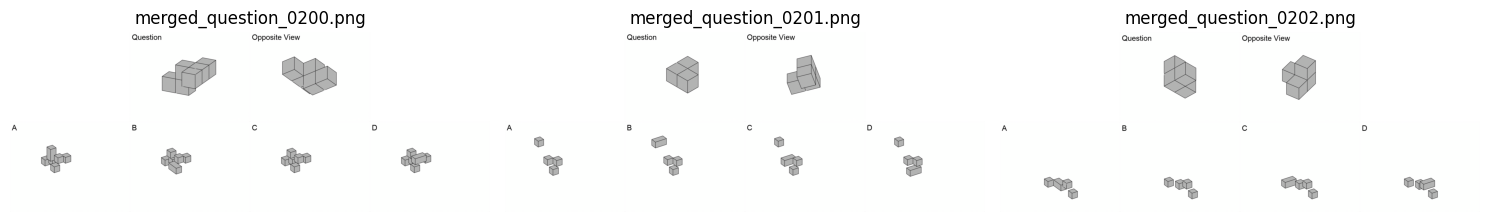

In [57]:
import os
import glob
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Locate dataset
# --------------------------------------------------
CSV_PATH = glob.glob("**/DISE-benchmark.csv", recursive=True)[0]
DATA_ROOT = os.path.dirname(CSV_PATH)

IMAGE_ROOT = os.path.join(DATA_ROOT, "images")

# --------------------------------------------------
# 2. Load questions ONLY (CSV is question table)
# --------------------------------------------------
questions = pd.read_csv(
    CSV_PATH,
    engine="python",
    on_bad_lines="skip",
    header=None
)

questions = questions.iloc[:, 0].astype(str).str.strip()
questions = questions[questions.str.len() > 10].reset_index(drop=True)

print("Number of questions:", len(questions))
print("\nSample questions:")
print(questions.head(3))

# --------------------------------------------------
# 3. Collect ALL images from folders (independent)
# --------------------------------------------------
image_files = sorted(
    glob.glob(os.path.join(IMAGE_ROOT, "**", "*.png"), recursive=True) +
    glob.glob(os.path.join(IMAGE_ROOT, "**", "*.jpg"), recursive=True)
)

print("\nNumber of images:", len(image_files))
print("Sample image paths:")
print(image_files[:3])

# --------------------------------------------------
# 4. Visualize a few images (no CSV coupling)
# --------------------------------------------------
def show_images(paths, n=3):
    n = min(n, len(paths))
    fig, axs = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axs = [axs]
    for i in range(n):
        img = Image.open(paths[i])
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(os.path.basename(paths[i]))
    plt.tight_layout()
    plt.show()

show_images(image_files, n=3)
